In [1]:
""" 
PROGRAM :  diagnostics_basics.ipynb 

reads in intpp assimilation runs, historical simulations 
and raw forecasts under CMIP6 emissions 
to produce some basic diagnostics

STATUS  : Complete 
COMMENTS: (1) No adjusted forecast shown her
"""

' \nPROGRAM :  diagnostics_basics.ipynb \n\nreads in intpp assimilation runs, historical simulations \nand raw forecasts under CMIP6 emissions \nto produce some basic diagnostics\n\nSTATUS  : Complete \nCOMMENTS: (1) No adjusted forecast shown her\n'

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.insert(1, '/home/rpg002/BGC_skill')

from fnmatch import fnmatch
import pandas as pd
import configs
from prepare import (prepare_data_for_analysis, 
                    load_ONI,
                     calculate_climatology, 
                     calculate_detrended,
                     spco2_decomposition,
                     get_corr_ONI,
                     experiment_finder)

from modules.plotting.module_plot_maps import *


In [3]:
units = configs.units
boundaries_dict = configs.boundaries_dict
model_lev_bounds = configs.model_lev_bounds
model_levels = configs.model_levels
unit_change_dics = configs.unit_change_dics
varx = configs.varx

### Configs

In [4]:
data_directory = '/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data'


assimilation_BGC_run_id = None
CanOE_assimilation_BGC_run_id = 1

var_list = [ 'spco2', 'chlos', 'thetao'] #,'talk','dissic', 'no3',  'silicate', 'po4']
experiment_list = ['observation','assimilation', 'historical']
model_list = ['CanESM5', 'CanESM5-CanOE']
obs_source = {'spco2' : 'SOMFFN',
              'chlos' : 'ESACCI',
              'thetao' : 'SODA'} 

 ## this could be a dictionary for each variable as they might have different sources.
decompose_spco2: bool = False
vars_to_det: list[str] =  None #['spco2']

### Data Loading

In [5]:
dict_em_data, obs_mask, model_mask , mask_ocean_surface = prepare_data_for_analysis(var_list,
                            experiment_list,
                            model_list,
                            obs_source,
                            data_directory ,
                            unit_change_dics,
                            assimilation_BGC_run_id = None,
                            CanOE_assimilation_BGC_run_id = 1,
                            nldyr = 1, 
                            varx_dicts = varx,
                            verbose = True)


observation directories: 

/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/spco2/observation/SOMFFN
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/chlos/observation/ESACCI
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/thetao/observation/SODA

model directories: 

spco2 assimilation: 
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/spco2/assimilation/CanESM5
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/spco2/assimilation/CanESM5-CanOE_1
spco2 historical: 
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/spco2/historical/CanESM5
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/spco2/historical/CanESM5-CanOE
chlos assimilation: 
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/chlos/assimilation/CanESM5
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/chlos/assimilation/CanESM5-CanOE_1
chlos historical: 
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/chlos/historical/CanESM5
/space/hall7/sitestore/eccc/crd

In [6]:
ONI_dict = load_ONI(experiment_list, 
                    model_list, 
                    assimilation_BGC_run_id,
                    CanOE_assimilation_BGC_run_id,
                    obs_source='ERSST')

In [7]:
idisplay=False

if idisplay:

    ax = plt.subplot(1,1,1)
    ax.pcolormesh(mask_ocean_surface.lon, mask_ocean_surface.lat, mask_ocean_surface.where(mask_ocean_surface ==0).values, vmin = 0, vmax =1)
    plt.scatter(-50.5, 43.5, color='red', s=10, label='My Point', zorder=10)

In [8]:
idisplay=False

if idisplay:
    print('checking loaded data')
    for var in dict_em_data:
        for exp in dict_em_data[var]:
            print(f'{var} {exp}')
            display(dict_em_data[var][exp].data)




### Data Prep

In [10]:
if decompose_spco2:
    dict_em_data = spco2_decomposition(dict_em_data)

In [21]:
# _, dict_em_anom = calculate_climatology(dict_em_data,
#                                                    y0_base=None,
#                                                    y1_base=None,
#                                                    return_anomaly=True)

dict_corr_anom = get_corr_ONI(dict_em_anom, ONI_dict)

In [ ]:
dict_em_det = calculate_detrended(dict_em_data,
                                  vars_to_det,
                                  month_specific_det=True
                                  )

if dict_em_det is not None:
    dict_corr_det = get_corr_ONI(dict_em_det, ONI_dict)

### Plots

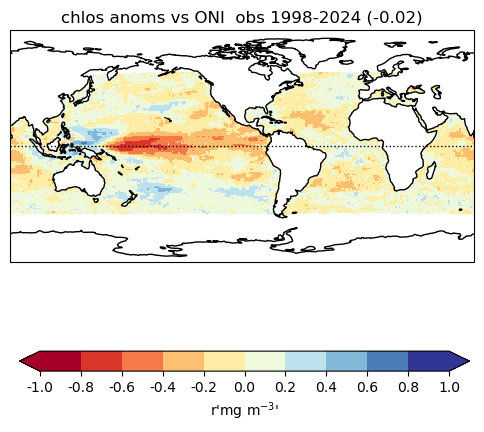

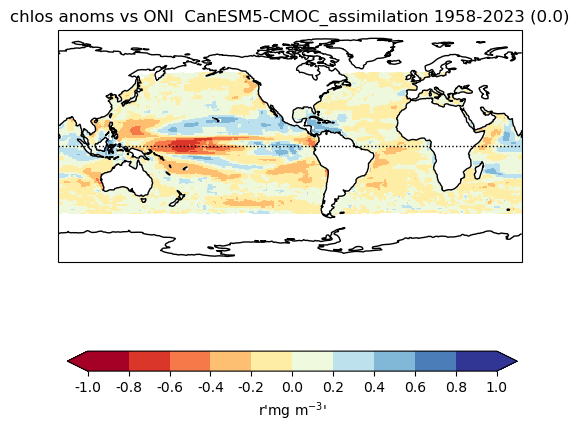

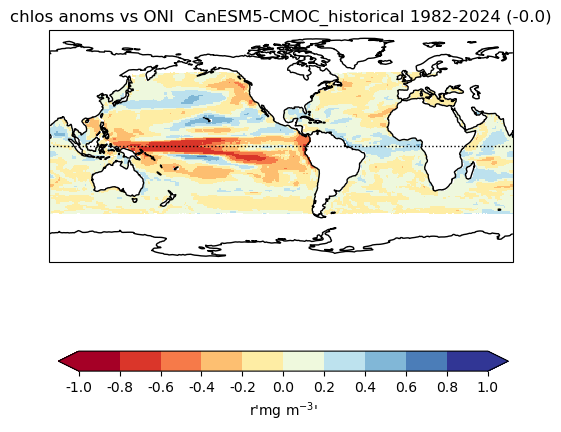

In [33]:
var = 'chlos'

model_experiment = ['observation', 'CanESM5 assimilation' , 'CanESM5 historical']

figsize = (5,5)

central_longitude = 260


datadict = dict_corr_anom[var]
ds_list = experiment_finder(datadict, model_experiment)

title = f'{var} anoms vs ONI '

plot_global_map(ds_list,
                    datadict,
                    figsize=figsize,                    
                    central_longitude=central_longitude,
                    cbar_label= units[var],  
                    title = title,
                    show_equator=True,
                    cbar=True,
                    nval = 20)
